<a href="https://colab.research.google.com/github/Apoorv070/AI-Agent-Revison-Notebooks/blob/main/6_Multi_Agent_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qU langchain langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 19.0 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [3]:
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END

## Shared state vs agent views

The workflow has one shared state, but we will not expose the full state to every agent.

### Shared state
This is the full workflow memory:
- customer_message
- issue_summary
- priority
- draft_reply
- final_reply

### Agent view
This is the smaller input we deliberately send to an agent.

For example:
- intake agent view = only customer_message
- writer agent view = only issue_summary and priority
- reviewer agent view = only draft_reply

So the graph may know more than the agent sees.
That is exactly the idea of controlled context.

In [4]:
class ComplaintState(TypedDict):
    customer_message: str
    issue_summary: str
    priority: str
    draft_reply: str
    final_reply: str

    intake_view_used: str
    writer_view_used: str
    reviewer_view_used: str

## Create the specialist agents

We will create three simple agents:

1. Intake agent  
   Understands the customer complaint

2. Writer agent  
   Drafts a support reply

3. Reviewer agent  
   Improves the drafted reply

Notice that each agent has a very narrow role.
That is what makes multi-agent systems easier to understand.

In [5]:
class IntakeOutput(BaseModel):
    issue_summary: str = Field(description="A short summary of the customer's issue")
    priority: Literal["low", "medium", "high"] = Field(description="Priority level")

class DraftOutput(BaseModel):
    draft_reply: str = Field(description="A polite draft reply to the customer")

class ReviewOutput(BaseModel):
    final_reply: str = Field(description="A clearer and slightly improved final reply")

In [6]:
intake_agent = create_agent(
    model="openai:gpt-4o-mini",
    response_format=IntakeOutput,
    system_prompt=(
        "You are an intake agent. "
        "Read the customer complaint and return only two things: "
        "a short issue summary and a priority label."
    ),
)

writer_agent = create_agent(
    model="openai:gpt-4o-mini",
    response_format=DraftOutput,
    system_prompt=(
        "You are a support reply writer. "
        "Write a short, polite customer support reply using the issue summary and priority."
    ),
)


reviewer_agent = create_agent(
    model="openai:gpt-4o-mini",
    response_format=ReviewOutput,
    system_prompt=(
        "You are a reviewer. "
        "Improve the drafted reply slightly so it sounds clear, polite, and professional."
    ),
)

## Node 1 — Intake agent

This agent should only see:
- the raw customer message

It should not see:
- any future draft reply
- any final reply
- anything from later stages

In [7]:

def intake_node(state:ComplaintState):
  # Define the view
  # This thing will take some coding
  # THis thing should be done with a separate function
  intake_view = {'customer_message': state['customer_message']}
  result = intake_agent.invoke(
      {
          "messages": [
              {
                  "role": "user",
                  "content": f"Customer message:\n{intake_view['customer_message']}"
              }
          ]
      }
  )
  output = result['structured_response']
  return {'issue_summary': output.issue_summary,
          'priority': output.priority,
          'intake_view_used': str(intake_view)}

In [8]:
# state = ComplaintState()
# state['customer_message'] = "Hi it's been two I have bot received the produce, please help!"
# result = intake_node(state)

In [9]:
# result

## Node 2 — Writer agent

This agent should only see:
- issue summary
- priority

It should not see:
- the full raw complaint
- the future final reply

In [10]:
def writer_node(state: ComplaintState):
    writer_view = {
        "issue_summary": state["issue_summary"],
        "priority": state["priority"]
    }

    result = writer_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": (
                        f"Issue summary: {writer_view['issue_summary']}\n"
                        f"Priority: {writer_view['priority']}\n\n"
                        "Write a customer support reply."
                    )
                }
            ]
        }
    )

    data = result["structured_response"]

    return {
        "draft_reply": data.draft_reply,
        "writer_view_used": str(writer_view)
    }

In [11]:
# state = ComplaintState()
# state['customer_message'] = 'Hi I have not received the product in 15 days now, please get me the refund'
# intake_node(state)

In [12]:
# # Trivial issue, but flagged as critical
# state["issue_summary"] = "Customer wants to know if the blue shirt comes in a slightly darker blue."
# state["priority"] = "CRITICAL"
# writer_node(state)

## Node 3 — Reviewer agent

This agent should only see:
- the drafted reply

It should not see:
- the original message
- the issue summary
- the full workflow state|

In [13]:
def reviewer_node(state: ComplaintState):
    reviewer_view = {
        "draft_reply": state["draft_reply"]
    }

    result = reviewer_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": f"Draft reply:\n{reviewer_view['draft_reply']}"
                }
            ]
        }
    )

    data = result["structured_response"]

    return {
        "final_reply": data.final_reply,
        "reviewer_view_used": str(reviewer_view)
    }

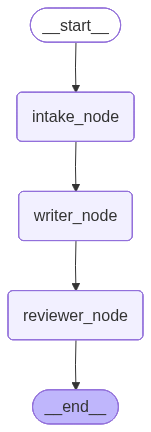

In [14]:
builder = StateGraph(ComplaintState)
builder.add_node("intake_node", intake_node)
builder.add_node("writer_node", writer_node)
builder.add_node("reviewer_node", reviewer_node)

builder.add_edge(START, "intake_node")
builder.add_edge("intake_node", "writer_node")
builder.add_edge("writer_node", "reviewer_node")
builder.add_edge("reviewer_node", END)
graph = builder.compile()
graph

In [ ]:
result = graph.invoke(
    {
        "customer_message": (
            "I was charged twice for the same order and nobody has replied yet. "
            "This is very frustrating."
        ),
        "issue_summary": "",
        "priority": "",
        "draft_reply": "",
        "final_reply": "",
        "intake_view_used": "",
        "writer_view_used": "",
        "reviewer_view_used": "",
    }
)
result

In [ ]:
print(result['final_reply'])